# Customer Churn Prediction — Working with a Business Problem

**Goal:** Predict which telecom customers are likely to churn (cancel their
service) — a real problem companies pay for across telecom, banking, and
SaaS. This notebook also introduces **Decision Trees**, a model type that's
easy to interpret and explain to non-technical stakeholders, and compares it
against Logistic Regression.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
(Kaggle) — 7,043 customers, 21 columns, target: `Churn` (Yes/No).


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("telco_churn.csv")
df.shape


(7043, 21)

## 2. First look at the data

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`TotalCharges` is stored as text (`object`) instead of a number — 11 rows
have a blank string instead of a value. These all turn out to be brand-new
customers with `tenure = 0` (they haven't been billed a full cycle yet), so I
convert the column to numeric and fill those blanks with 0.


In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing after conversion:", df["TotalCharges"].isnull().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])  # identifier, not predictive


Missing after conversion: 11


## 3. Quick EDA — what correlates with churn?

In [5]:
df["Churn"].value_counts(normalize=True).round(3)


Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

**Class imbalance note:** about 73.5% of customers did *not* churn vs. 26.5%
who did. This is a real class imbalance we should keep in mind when
interpreting accuracy later — a model could get ~73.5% accuracy just by
predicting "No churn" for everyone, without being useful at all. We don't
fully correct for it in this task (e.g. no SMOTE/resampling), but we do use
`stratify` in the train/test split and look at precision/recall per class,
not just accuracy.


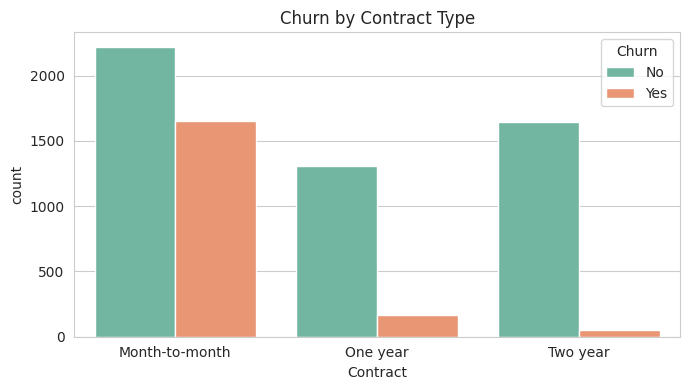

In [6]:
plt.figure(figsize=(7, 4))
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")
plt.title("Churn by Contract Type")
plt.tight_layout()
plt.show()


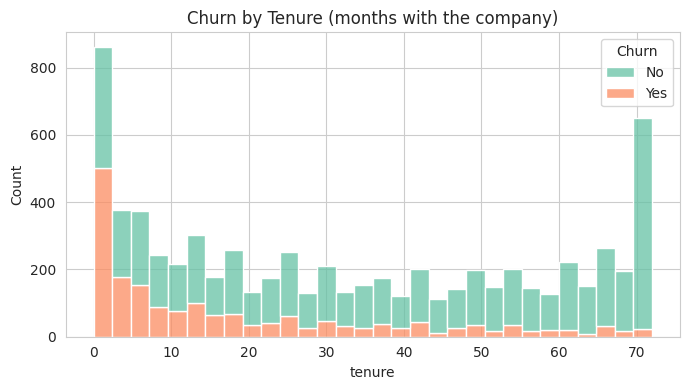

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette="Set2")
plt.title("Churn by Tenure (months with the company)")
plt.tight_layout()
plt.show()


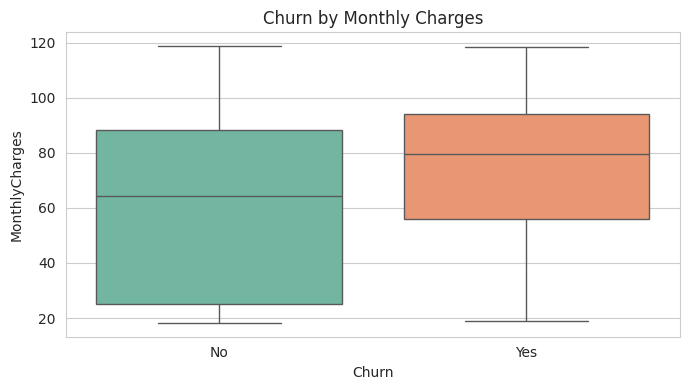

In [8]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, hue="Churn", palette="Set2", legend=False)
plt.title("Churn by Monthly Charges")
plt.tight_layout()
plt.show()


From these plots: customers on a **month-to-month contract** churn far more
than those on 1- or 2-year contracts, customers with **low tenure** (new
customers) churn much more than long-tenured ones, and customers with
**higher monthly charges** tend to churn more than those paying less.


## 4. Encode categorical variables

In [9]:
target = (df["Churn"] == "Yes").astype(int)
features = df.drop(columns=["Churn"])

categorical_cols = features.select_dtypes(include="object").columns.tolist()
print(f"{len(categorical_cols)} categorical columns:", categorical_cols)

features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
features_encoded.shape


15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_479/2555967011.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = features.select_dtypes(include="object").columns.tolist()


(7043, 30)

## 5. Train/test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (5634, 30)  Test: (1409, 30)


## 6. Train two models: Logistic Regression and Decision Tree

In [11]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 7. Compare performance

In [12]:
def eval_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    eval_model("Logistic Regression", y_test, y_pred_lr),
    eval_model("Decision Tree", y_test, y_pred_tree),
]).round(4)
results


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8062,0.6593,0.5588,0.6049
1,Decision Tree,0.7942,0.6312,0.5401,0.5821


In [13]:
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))
print("Decision Tree:")
print(classification_report(y_test, y_pred_tree, target_names=["No Churn", "Churn"]))


Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Decision Tree:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



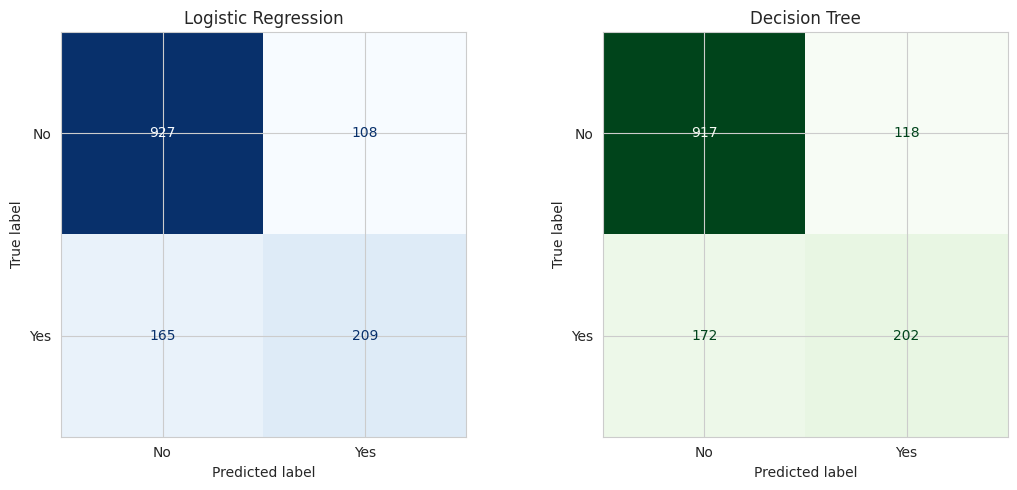

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=["No", "Yes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tree), display_labels=["No", "Yes"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Decision Tree")
plt.tight_layout()
plt.show()


## 8. Top 3 features driving churn (Decision Tree)

Top 3 features driving churn:
                        feature  importance
1                        tenure    0.422047
10  InternetService_Fiber optic    0.358061
3                  TotalCharges    0.037156


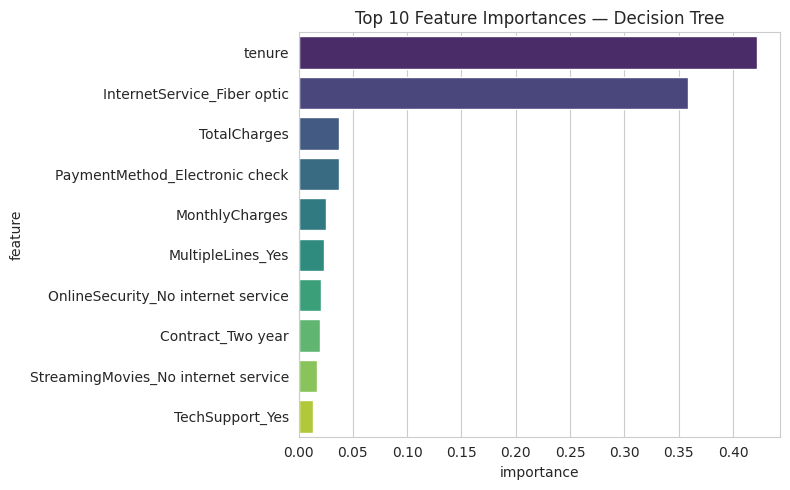

In [15]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=False)

top3 = importances.head(3)
print("Top 3 features driving churn:")
print(top3)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=importances.head(10), hue="feature", palette="viridis", legend=False)
plt.title("Top 10 Feature Importances — Decision Tree")
plt.tight_layout()
plt.show()


## 9. Business summary (for a non-technical manager)

Roughly 1 in 4 of our customers churn, and the pattern is consistent and
actionable: customers on **month-to-month contracts**, with **short tenure**,
and **higher monthly bills** are by far the most likely to leave — the top
churn signals identified by the model align exactly with what we saw in the
EDA. This means our biggest churn risk is concentrated in new, flexible-plan
customers rather than being spread evenly across the base. The most direct
lever we have is incentivizing longer-term contracts (discounts for 1-2 year
commitments) and paying extra attention to customers in their first few
months, since that's where we stand to prevent the most cancellations. Both
models we tested can flag at-risk customers well above chance, giving us a
practical way to prioritize retention outreach rather than guessing who to
call.
